# In this notebook we will test how well llm understands the color of an object.

In [1]:
import torch
from transformers import AutoTokenizer
from vl_code.modeling_internvl_chat import InternVLChatModel

/home/jovyan/.mlspace/envs/interpretation_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FlashAttention2 is not installed.


/home/jovyan/.mlspace/envs/interpretation_env/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
device = 'cuda:0'
vision_model_name = 'OpenGVLab/Mini-InternVL-Chat-2B-V1-5'
vision_weights_dir = '../weights'
tokenizer = AutoTokenizer.from_pretrained(vision_model_name, cache_dir=vision_weights_dir, trust_remote_code=True, use_fast=False)
llm = InternVLChatModel.from_pretrained(
    vision_model_name, 
    cache_dir=vision_weights_dir,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True).eval().cuda()

InternLM2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


## We calculate the percentage of correct answers.

In [3]:
import os
import json
import numpy as np
from tqdm import tqdm
from utils_for_llm import load_image_from_pil
from utils_for_task_generation import generate_random_shape_image

generation_config = dict(max_new_tokens=1024, do_sample=False, num_beams=4)
question = '<image>\n'+\
           'What color is the figure and what color is background?'+\
           'Choose only one from three options: red, green, blue.'+\
           'Give answer in json format "{shape_color: <color name: red, green or blue>, background_color: <color name: red, green or blue>}"'

save_path = './images/images_check'
shape_types = ["polygon", "ellipse"]
#            red          green        blue
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]
color_names = ['red', 'green', 'blue']

N = 100
correctnes_shape_color = []
correctnes_background_color = []
images = []

expected_color_shape = []
expected_color_background = []

answers_color_shape = []
answers_color_background = []
for i in tqdm(range(N)):
    shape_type_id = np.random.choice([0, 1])
    color_id = np.random.choice([0, 1, 2])
    expected_color = color_names[color_id]

    background_color_id = np.random.choice(list({0, 1, 2} - {color_id}))
    expected_back_color = color_names[background_color_id]

    expected_color_shape.append(expected_color)
    expected_color_background.append(expected_back_color)

    if save_path is not None:
        output_path = os.path.join(save_path, f'{i}.png')
    else:
        output_path = None
    image = generate_random_shape_image(shape_type=shape_types[shape_type_id], 
                                        color=colors[color_id], 
                                        background_color=colors[background_color_id], 
                                        output_path=output_path)
    images.append(image)
    pixel_values = load_image_from_pil(image, transform=None, max_num=1).to(torch.bfloat16).cuda()
    response = llm.chat(tokenizer, pixel_values, question, generation_config)

    cleaned_json = response.strip().removeprefix('```json').removesuffix('```').strip()
    cleaned_json = json.loads(cleaned_json)

    ans_color_shape = cleaned_json['shape_color']
    ans_color_background = cleaned_json['background_color']    
    answers_color_shape.append(ans_color_shape)
    answers_color_background.append(ans_color_background)

    correctnes_shape_color.append(ans_color_shape == expected_color)
    correctnes_background_color.append(ans_color_background == expected_back_color)
correctnes_total = np.array(correctnes_background_color) & np.array(correctnes_shape_color)

print(f'color of shape correctnes: {np.mean(correctnes_shape_color).round(2)}')
print(f'color of background correctnes: {np.mean(correctnes_background_color).round(2)}')
print(f'total correctnes: {np.mean(correctnes_total).round(2)}')

100%|██████████| 100/100 [01:12<00:00,  1.38it/s]

color of shape correctnes: 1.0
color of background correctnes: 1.0
total correctnes: 1.0


In [4]:
B = 10000
bootstrap_samples = np.array([
    np.random.choice(correctnes_total, size=len(correctnes_total))
    for _ in range(B)
    ])

bootstrap_estimates = bootstrap_samples.mean(axis=-1)
left_side = np.percentile(bootstrap_estimates, 2.5).round(3)
right_side = np.percentile(bootstrap_estimates, 97.5).round(3)

print(f'mean: {np.mean(correctnes_total).round(3)}')
print(f'95% confidence interval: [{left_side}, {right_side}]')

mean: 1.0
95% confidence interval: [1.0, 1.0]


## Let's see what the generated dataset looks like.

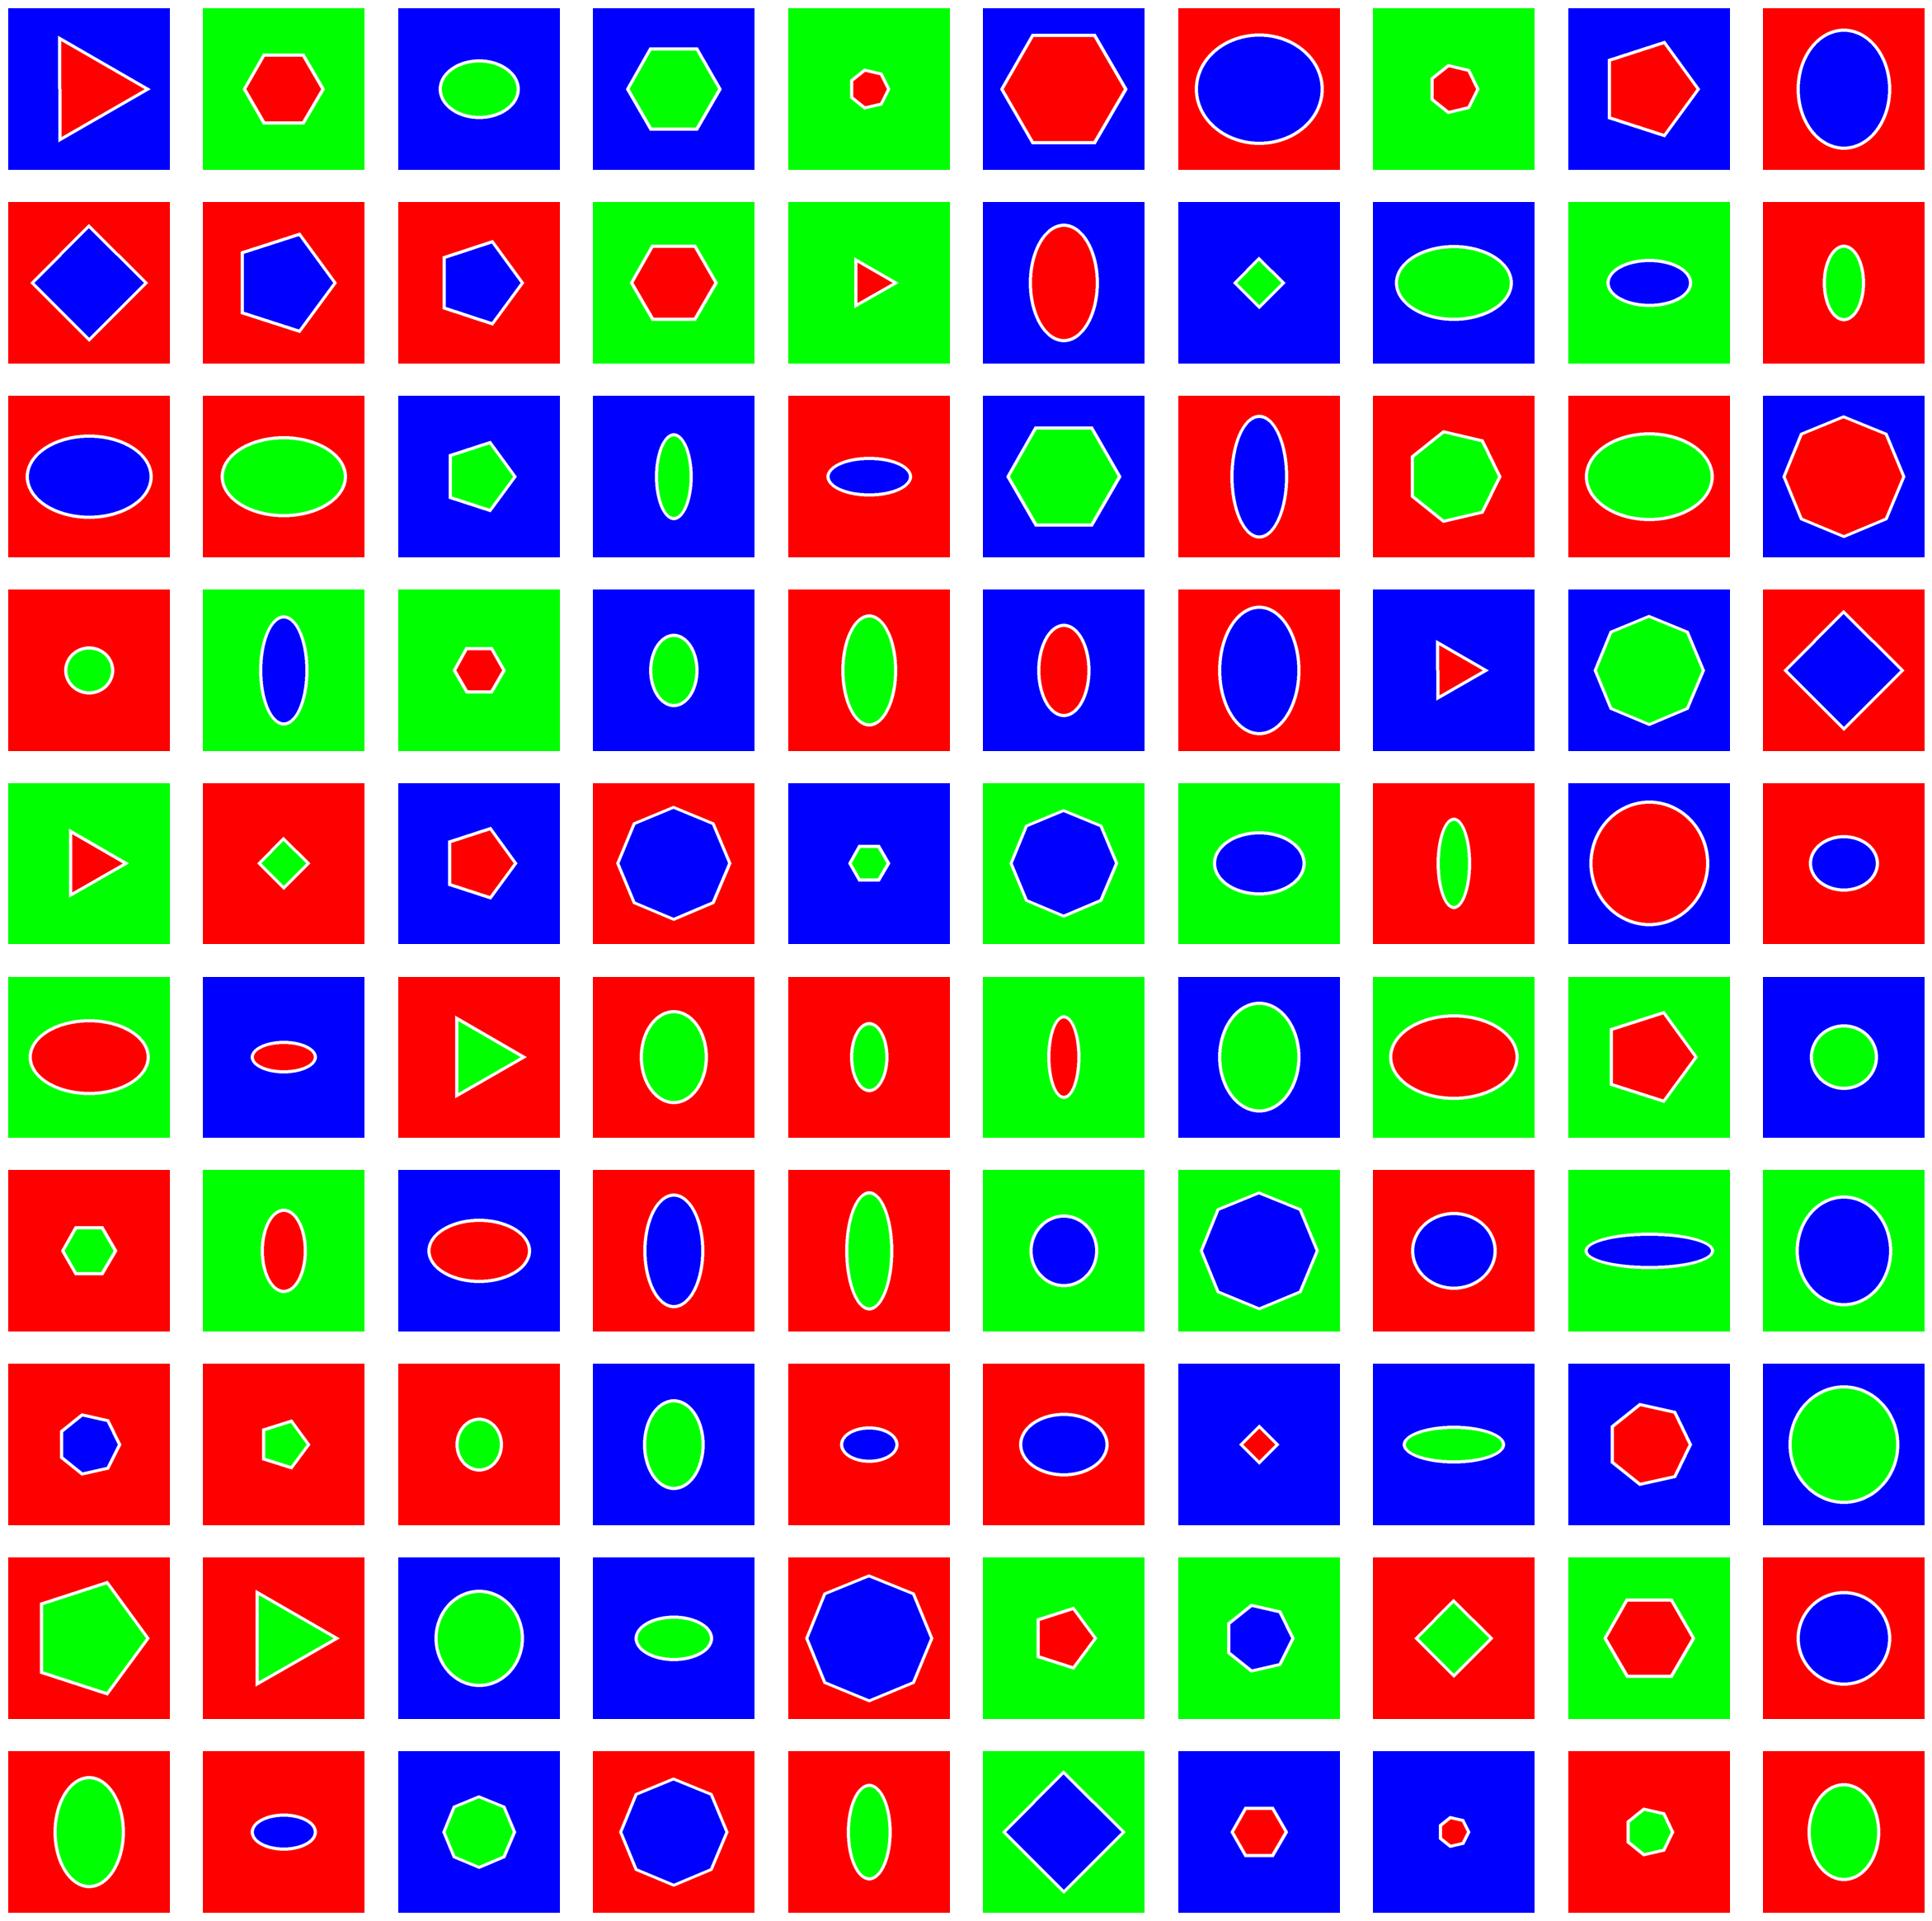

In [5]:
import matplotlib.pyplot as plt
ncols, nrows, scale = int(N**0.5), int(N**0.5), 3
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(ncols * scale, nrows * scale))

for i, (ans_color_shape, ans_background_shape, img) in enumerate(zip(answers_color_shape, answers_color_background, images)):
    axes[i//ncols, i%ncols].imshow(np.array(img))
    axes[i//ncols, i%ncols].axis('off')

## Let's apply the reconstructor to the features and see what the corresponding images look like.

In [6]:
import sys
if '../reconstructor' not in sys.path:
    sys.path.append('../reconstructor')
from model import VQVAE

reconstructor_weights_path = '../reconstructor/checkpoint/num-hidden-layers-4/vqvae-040.pt'
model = VQVAE(vision_model_name, vision_weights_dir, calc_cos=False).to(device)
model.load_state_dict(torch.load(reconstructor_weights_path, weights_only=True), strict=True)
model.eval();

You are using a model of type intern_vit_6b to instantiate a model of type clip_vision_model. This is not supported for all configurations of models and can yield errors.


In [7]:
from PIL import Image
from utils_for_feature_transformation import Qed
shapes_path = './images/images_check'
examples_pathes = [os.path.join(shapes_path, n) for n in os.listdir(shapes_path) if '.png' in n][:N]
examples = [Image.open(ep).convert('RGB') for ep in examples_pathes]

inputs_list, features_list, Qed_features_list, processed_inputs_list, processed_features_list = Qed(llm, examples, Q=None, n=1)

  1%|          | 1/100 [00:00<00:11,  8.72it/s]

Q.shape=torch.Size([1024, 1024])


100%|██████████| 100/100 [00:13<00:00,  7.24it/s]


In [8]:
from utils_for_feature_transformation import interpolate_all_features
inter_list, rec_list, processed_inter_list, processed_rec_list, Qed_rec_list = \
interpolate_all_features(model, inputs_list, features_list, Qed_features_list, 
                         processed_inputs_list, processed_features_list, device)

  0%|          | 0/100 [00:00<?, ?it/s]/mnt/virtual_ai0001053-00054_SR004-nfs2/allakhverdov/feature_analysis/transformed_features_in_vlm/experiments/utils_for_feature_transformation.py:93: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  processed_image = torch.tensor(im).to(device).float()
100%|██████████| 100/100 [00:17<00:00,  5.81it/s]


In [9]:
save_path = './images/reconstruction_check'
for i, im in enumerate(Qed_rec_list):
    im = Image.fromarray(im.transpose(1, 2, 0))
    im.save(os.path.join(save_path, f'{i}.png'))

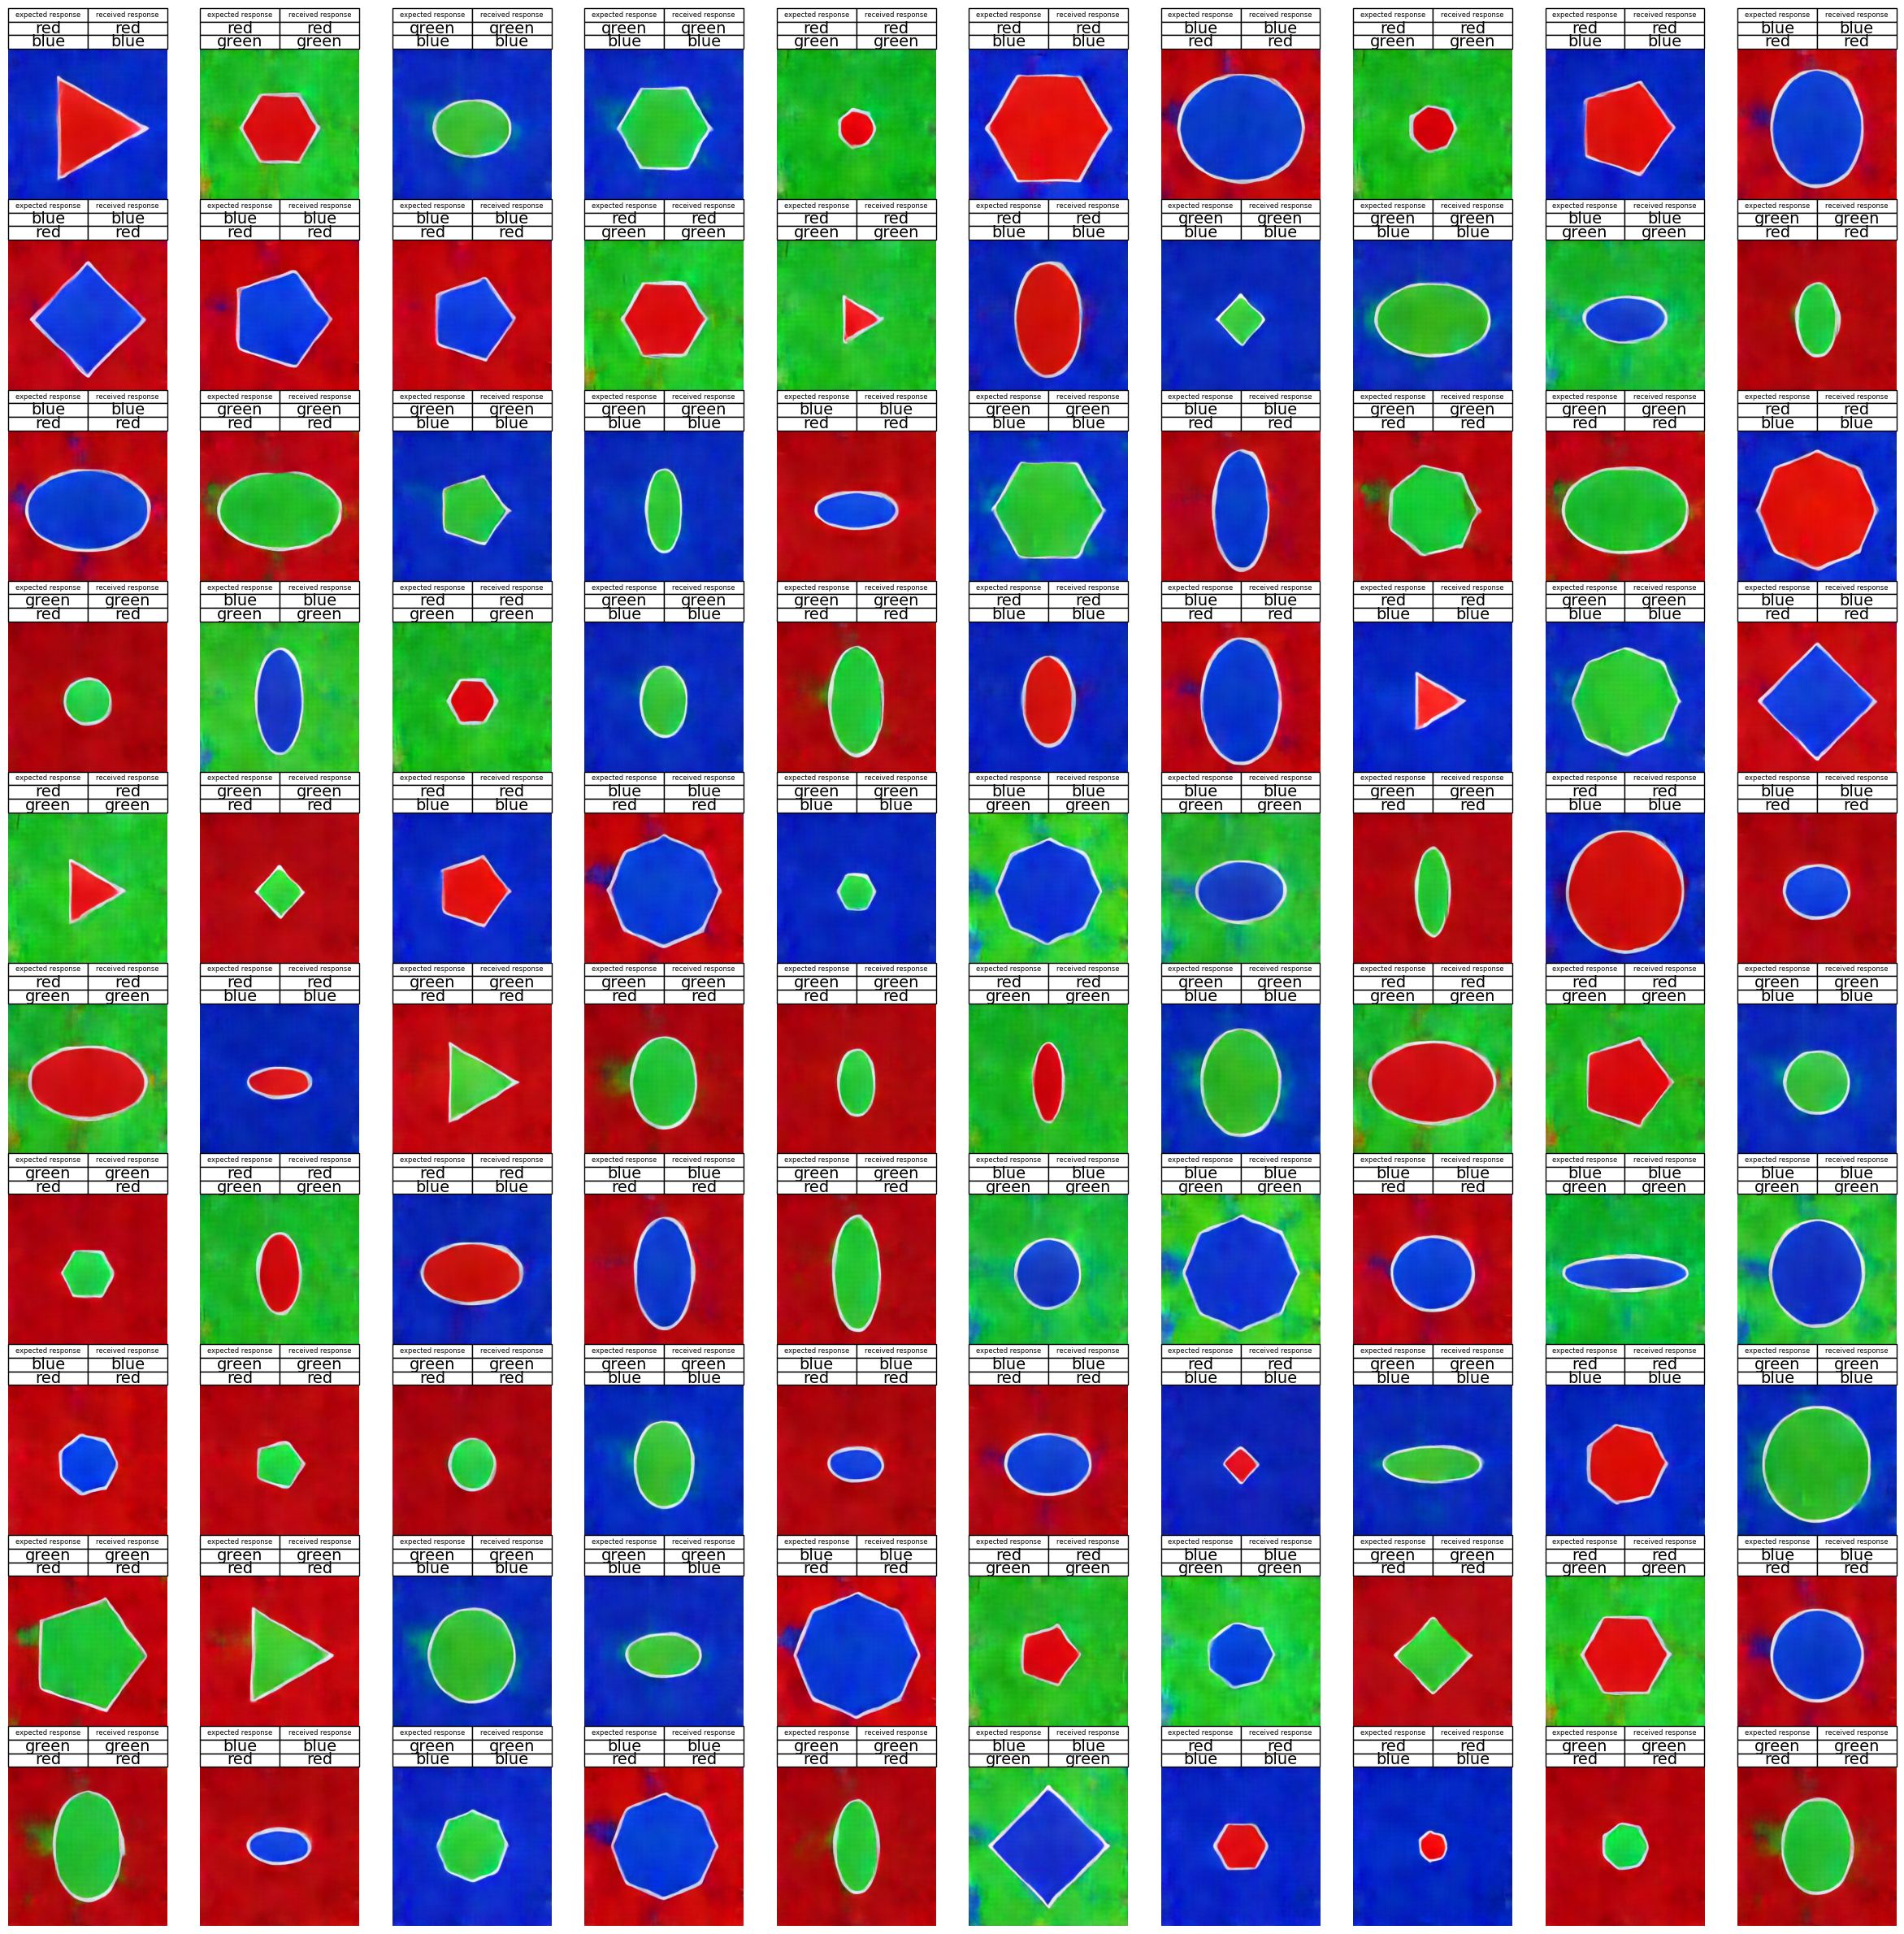

In [10]:
import matplotlib.pyplot as plt
ncols, nrows, scale = int(N**0.5), int(N**0.5), 3
fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(ncols * scale, nrows * scale))

reconstruction_path = './images/reconstruction_check'
examples_pathes = [os.path.join(reconstruction_path, n) for n in os.listdir(reconstruction_path) if '.png' in n]
examples = [Image.open(ep).convert('RGB') for ep in examples_pathes]

for i, (expected_color, expected_back_color, 
        ans_color_shape, ans_background_shape, 
        cor_shape, cor_background, img) in enumerate(
    zip(expected_color_shape, expected_color_background, 
        answers_color_shape, answers_color_background,
        correctnes_shape_color, correctnes_background_color, examples)):
    axes[i//ncols, i%ncols].imshow(np.array(img))
    
    table_data = [
        ['expected response', 'received response'],
        [expected_color, ans_color_shape],
        [expected_back_color, ans_background_shape]
    ]

    if cor_shape and cor_background:
        cell_colors = [["#FFFFFF"] * 2, ["#FFFFFF"] * 2, ["#FFFFFF"] * 2]
    elif (not cor_shape) and (not cor_background):
        cell_colors = [["#FFFFFF"] * 2, ["#FFFFFF", "#FF0000"], ["#FFFFFF", "#FF0000"]]
    elif not cor_shape:
        cell_colors = [["#FFFFFF"] * 2, ["#FFFFFF", "#FF0000"], ["#FFFFFF"] * 2]
    elif not cor_background:
        cell_colors = [["#FFFFFF"] * 2, ["#FFFFFF"] * 2, ["#FFFFFF", "#FF0000"]]


    table = axes[i//ncols, i%ncols].table(cellText=table_data,
                  loc='top',
                  cellLoc='center',
                  colWidths=[0.5, 0.5], 
                  cellColours=cell_colors,
                  )
    table.auto_set_font_size(False)
    table.set_fontsize(6)
    for j in range(1, 3):
        table[(j, 0)].set_text_props(fontsize=14)
        table[(j, 1)].set_text_props(fontsize=14)

    axes[i//ncols, i%ncols].axis('off')